## 1 Creating and Manipulating Arrays

In [18]:
import numpy as np
from matplotlib import pyplot as plt

### 1.1. Create two 2D arrays representing coordinates x, y on the cartesian plan
Both should cover the range (-2, 2) and have 100 points in each directio

In [3]:
x = np.linspace(-2,2,100)
y = np.linspace(-2,2,100)

In [4]:
X,Y = np.meshgrid(x,y)

In [5]:
X,Y.shape

(array([[-2.        , -1.95959596, -1.91919192, ...,  1.91919192,
          1.95959596,  2.        ],
        [-2.        , -1.95959596, -1.91919192, ...,  1.91919192,
          1.95959596,  2.        ],
        [-2.        , -1.95959596, -1.91919192, ...,  1.91919192,
          1.95959596,  2.        ],
        ...,
        [-2.        , -1.95959596, -1.91919192, ...,  1.91919192,
          1.95959596,  2.        ],
        [-2.        , -1.95959596, -1.91919192, ...,  1.91919192,
          1.95959596,  2.        ],
        [-2.        , -1.95959596, -1.91919192, ...,  1.91919192,
          1.95959596,  2.        ]]),
 (100, 100))

### 1.2. Visualize each 2D array using pcolormesh
Use the correct coordiantes for the x and y axes.

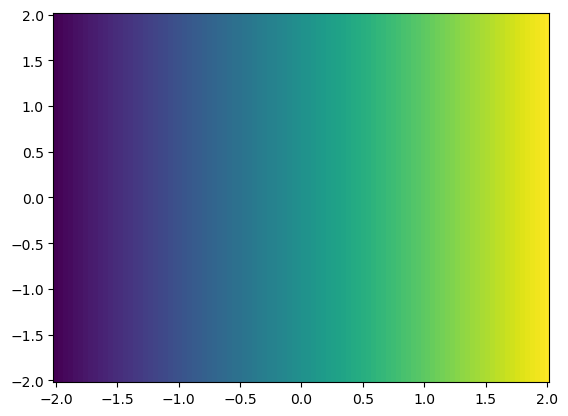

In [6]:
plt.pcolormesh(x,y,X)

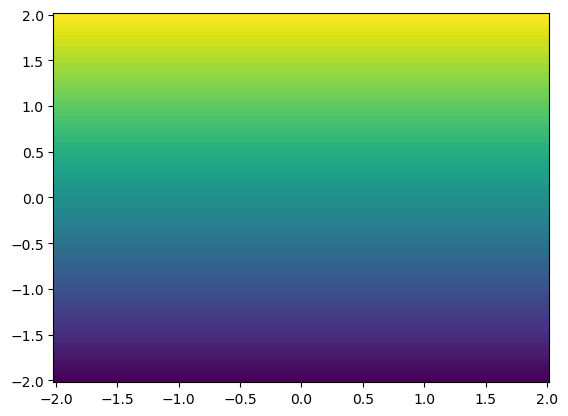

In [7]:
plt.pcolormesh(x,y,Y)

### 1.3 From your cartesian coordinates, create polar coordinates r and φ


In [9]:
r = np.sqrt(X**2 + Y**2)
φ = np.arctan2(Y,X)

### 1.4. Visualize1.3

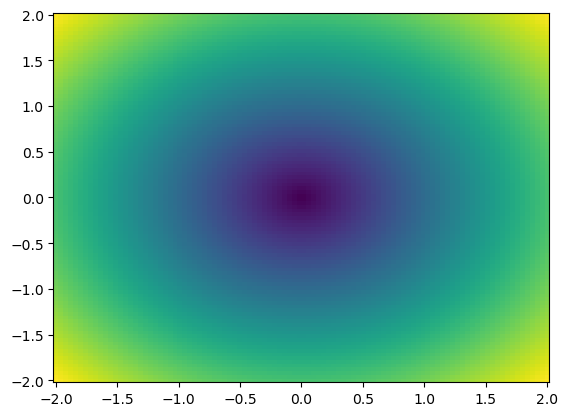

In [10]:
plt.pcolormesh(X,Y,r)

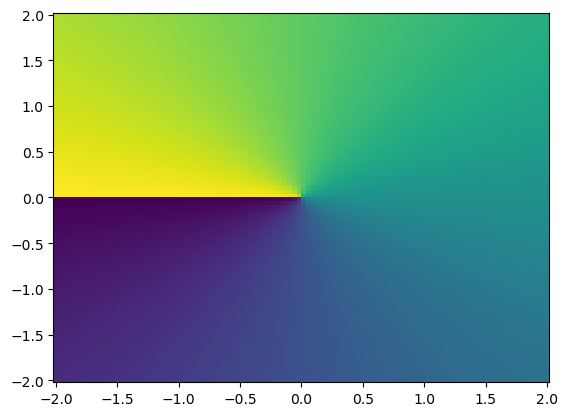

In [11]:
plt.pcolormesh(X,Y,φ)

### 1.5 Caclulate


In [12]:
f = (np.cos(4*r))**2+(np.sin(4*φ))**2

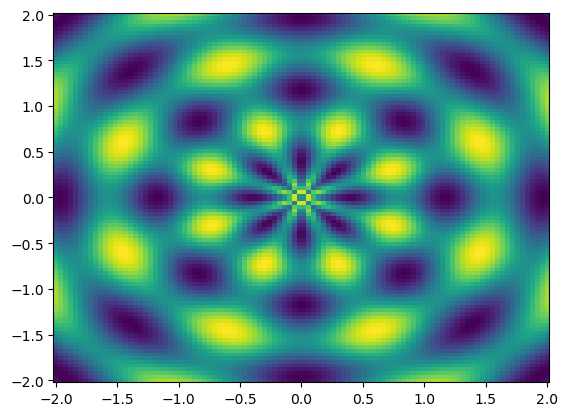

In [15]:
plt.pcolormesh(X,Y,f)

## 2.Analyze ARGO Data

In [16]:
import pooch

In [17]:
url = "https://www.ldeo.columbia.edu/~danielmw/float_data.zip"
files = pooch.retrieve(url, processor=pooch.Unzip(), known_hash="2a703c720302c682f1662181d329c9f22f9f10e1539dc2d6082160a469165009")
files

Unzipping contents of '/home/xm2357/.cache/pooch/182581396e4937a1fb09550d60cbc382-float_data.zip' to '/home/xm2357/.cache/pooch/182581396e4937a1fb09550d60cbc382-float_data.zip.unzip'


['/home/xm2357/.cache/pooch/182581396e4937a1fb09550d60cbc382-float_data.zip.unzip/float_data/date.npy',
 '/home/xm2357/.cache/pooch/182581396e4937a1fb09550d60cbc382-float_data.zip.unzip/float_data/T.npy',
 '/home/xm2357/.cache/pooch/182581396e4937a1fb09550d60cbc382-float_data.zip.unzip/float_data/S.npy',
 '/home/xm2357/.cache/pooch/182581396e4937a1fb09550d60cbc382-float_data.zip.unzip/float_data/P.npy',
 '/home/xm2357/.cache/pooch/182581396e4937a1fb09550d60cbc382-float_data.zip.unzip/float_data/levels.npy',
 '/home/xm2357/.cache/pooch/182581396e4937a1fb09550d60cbc382-float_data.zip.unzip/float_data/lon.npy',
 '/home/xm2357/.cache/pooch/182581396e4937a1fb09550d60cbc382-float_data.zip.unzip/float_data/lat.npy']

### 2.1 Load each data file as a numpy array

In [21]:
date = np.load('/home/xm2357/.cache/pooch/182581396e4937a1fb09550d60cbc382-float_data.zip.unzip/float_data/date.npy')

In [24]:
T = np.load( '/home/xm2357/.cache/pooch/182581396e4937a1fb09550d60cbc382-float_data.zip.unzip/float_data/T.npy')

In [25]:
S = np.load('/home/xm2357/.cache/pooch/182581396e4937a1fb09550d60cbc382-float_data.zip.unzip/float_data/S.npy')
P = np.load('/home/xm2357/.cache/pooch/182581396e4937a1fb09550d60cbc382-float_data.zip.unzip/float_data/P.npy')
level = np.load('/home/xm2357/.cache/pooch/182581396e4937a1fb09550d60cbc382-float_data.zip.unzip/float_data/levels.npy')
lon = np.load('/home/xm2357/.cache/pooch/182581396e4937a1fb09550d60cbc382-float_data.zip.unzip/float_data/lon.npy')
lat = np.load('/home/xm2357/.cache/pooch/182581396e4937a1fb09550d60cbc382-float_data.zip.unzip/float_data/lat.npy')

### 2.2 Examine the shapes of T, S and P compared to lon, lat, date and level. How do you think they are related?

In [26]:
T.shape

(78, 75)

In [27]:
S.shape

(78, 75)

In [28]:
P.shape

(78, 75)

In [29]:
lon.shape

(75,)

In [30]:
lat.shape

(75,)

In [31]:
date.shape

(75,)

In [33]:
level.shape

(78,)

#### 2.2Based on the shapes, which dimensions do you think are shared among the arrays? 
##### lon ,lat, data and level are one-dimension arrays, which contain 75 or 78 elements.
##### T, S and P are two-D arraies,(78,75). 
##### For these arrays above, the identical number indicates the shared dimension.

### 2.3 Make a plot for each column of data in T, S and P (three plots).
The vertical scale should be the levels data. Each plot should have a line for each column of data. It will look messy.

Text(0.5, 1.0, 'Ocean Temperatures Change with Depth levels')

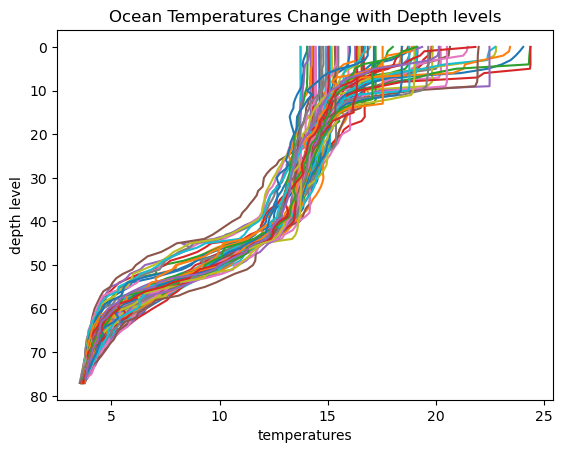

In [48]:
plt.plot(T, level)
plt.gca().invert_yaxis()
plt.xlabel('temperatures')
plt.ylabel('depth level')
plt.title('Ocean Temperatures Change with Depth levels')

Text(0.5, 1.0, 'Ocean Salinity Changes with Depth Levels')

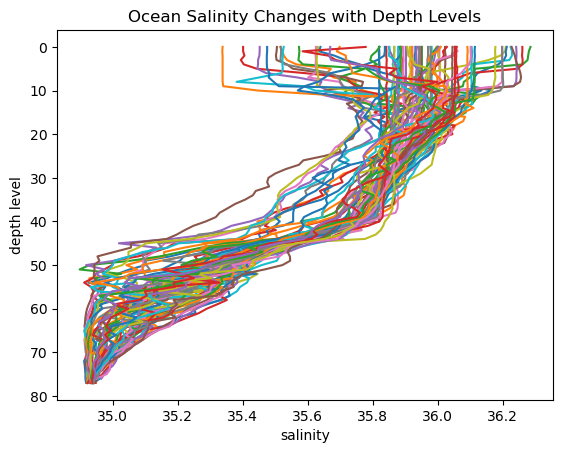

In [54]:
plt.plot(S,level)
plt.gca().invert_yaxis()
plt.xlabel('salinity')
plt.ylabel('depth level')
plt.title('Ocean Salinity Changes with Depth Levels')

Text(0.5, 1.0, 'Ocean Pressure Changes with Depth Levels')

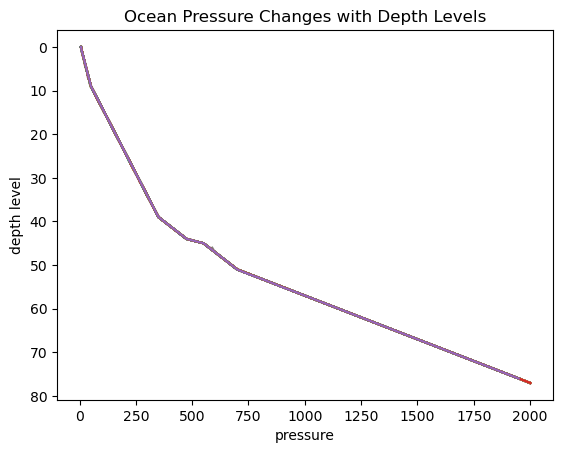

In [55]:
plt.plot(P,level)
plt.gca().invert_yaxis()
plt.xlabel('pressure')
plt.ylabel('depth level')
plt.title('Ocean Pressure Changes with Depth Levels')

### 2.4 Compute the mean and standard deviation of each of T, S and P at each depth in level.

In [61]:
T_mean = np.mean(T,axis =1)
T_sd = np.std(T,axis = 1)

In [62]:
S_mean = np.mean(S,axis = 1)
S_std = np.std(S,axis =1)

In [63]:
P_mean = np.mean(P,axis =1)
P_std = np.std(P,axis =1)

### 2.5 Now make three similar plot, but show only the mean T, S and P at each depth. Show error bars on each plot using the standard deviations

Text(0.5, 1.0, 'Ocean Mean Temperatre with Std')

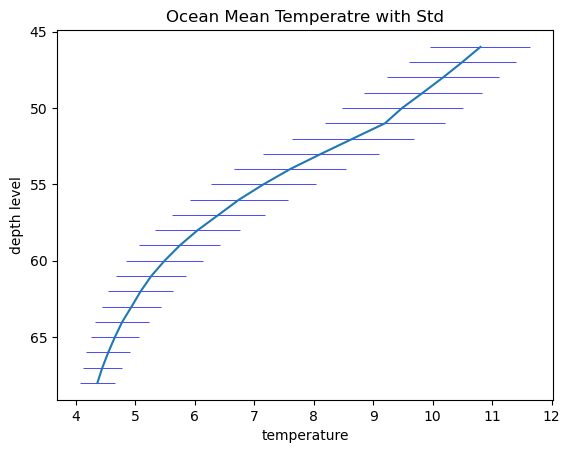

In [80]:
plt.errorbar(T_mean,level,xerr = T_sd,ecolor='blue',elinewidth=0.5)
plt.gca().invert_yaxis()
plt.xlabel('temperature')
plt.ylabel('depth level')
plt.title('Ocean Mean Temperatre with Std')

Text(0.5, 1.0, 'Ocean Mean Salinity with Std')

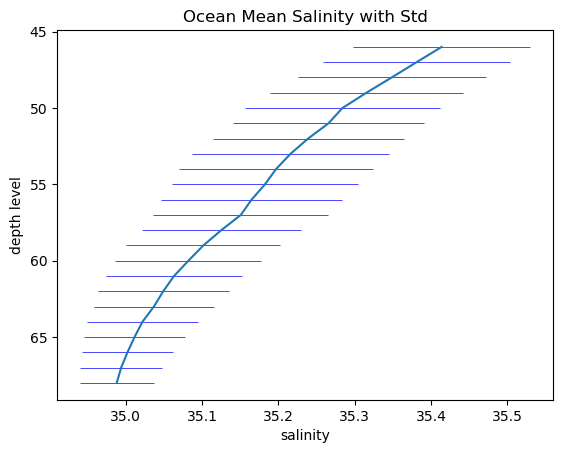

In [83]:
plt.errorbar(S_mean,level,xerr= S_std,ecolor='blue',elinewidth=0.5)
plt.gca().invert_yaxis()
plt.xlabel('salinity')
plt.ylabel('depth level')
plt.title('Ocean Mean Salinity with Std')

Text(0.5, 1.0, 'Ocean Mean Pressure with Std')

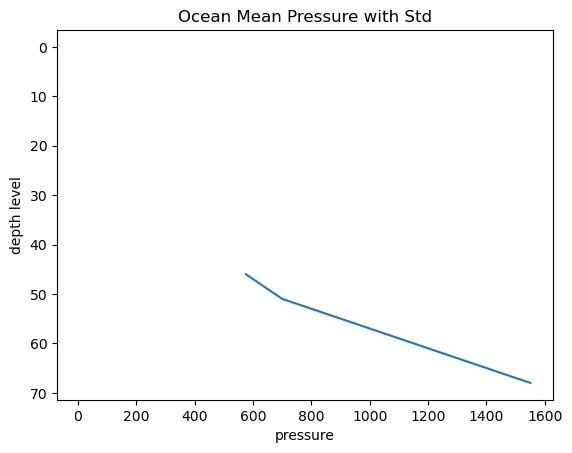

In [84]:
plt.errorbar(P_mean,level,xerr= P_std,ecolor='blue',elinewidth=0.5)
plt.gca().invert_yaxis()
plt.xlabel('pressure')
plt.ylabel('depth level')
plt.title('Ocean Mean Pressure with Std')

### 2.6 Account For Missing Data
Recalculate the means and standard deviations as in the previous sections using these functions and plot the results.

In [90]:
T_mean_nan = np.nanmean(T,axis =1)
T_sd_nan = np.nanstd(T,axis = 1)
S_mean_nan = np.nanmean(S,axis = 1)
S_std_nan = np.nanstd(S,axis =1)
P_mean_nan = np.nanmean(P,axis =1)
P_std_nan = np.nanstd(P,axis =1)

Text(0.5, 1.0, 'Ocean Mean Temperatre with Std')

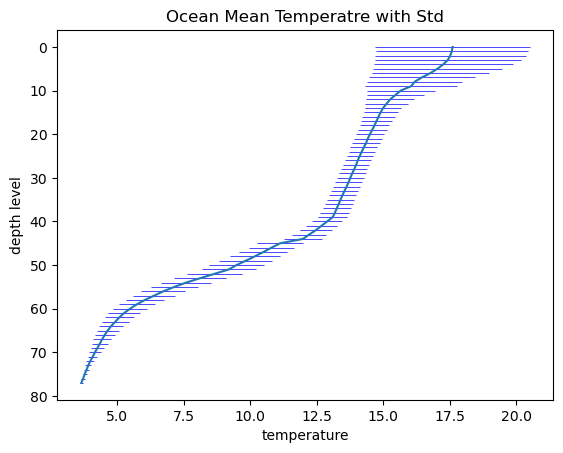

In [91]:
plt.errorbar(T_mean_nan,level,xerr = T_sd_nan,ecolor='blue',elinewidth=0.5)
plt.gca().invert_yaxis()
plt.xlabel('temperature')
plt.ylabel('depth level')
plt.title('Ocean Mean Temperatre with Std')

Text(0.5, 1.0, 'Ocean Mean Salinity with Std')

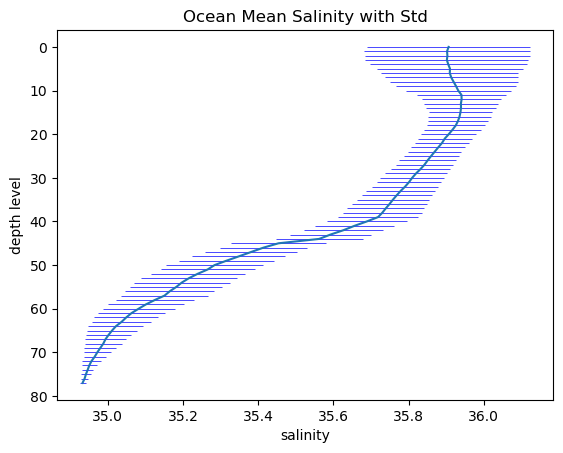

In [92]:
plt.errorbar(S_mean_nan,level,xerr= S_std_nan,ecolor='blue',elinewidth=0.5)
plt.gca().invert_yaxis()
plt.xlabel('salinity')
plt.ylabel('depth level')
plt.title('Ocean Mean Salinity with Std')

Text(0.5, 1.0, 'Ocean Mean Pressure with Std')

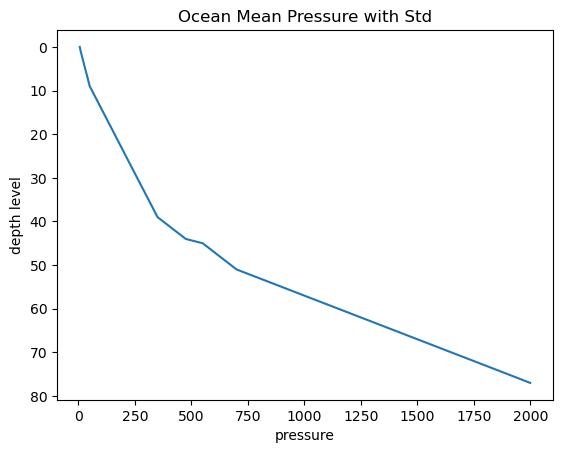

In [93]:
plt.errorbar(P_mean_nan,level,xerr= P_std_nan,ecolor='blue',elinewidth=0.5)
plt.gca().invert_yaxis()
plt.xlabel('pressure')
plt.ylabel('depth level')
plt.title('Ocean Mean Pressure with Std')

### 2.7 Create a scatter plot of the lon, lat positions of the ARGO float.

Text(0.5, 1.0, 'ARGO float')

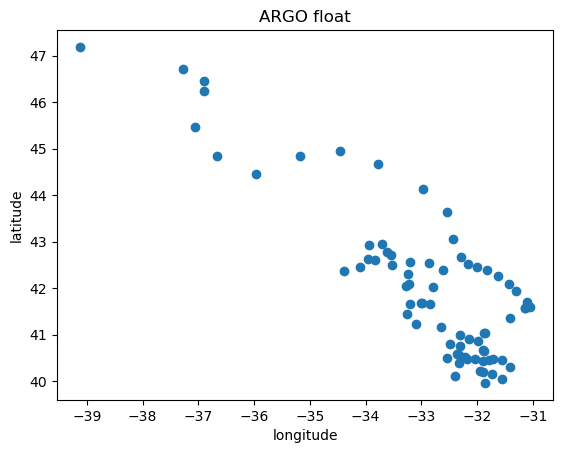

In [95]:
plt.scatter(lon,lat)
plt.xlabel('longitude')
plt.ylabel('latitude')
plt.title('ARGO float')